# `HealPixDecomp`: local multiscale decomposition

This notebook validates the exactly reconstructing Laplacian pyramid on an irregular NESTED HEALPix domain. The artificial mask mimics an ocean/land coastline. The test covers `Jmax=-1`, native-resolution metadata, exact inversion, explicit fine-grid summation, NumPy interoperability, and Torch autograd.

`u` and `v` are decomposed as independent channels. The `HealPixMultiScaleDivCurl` operator can now apply scale-dependent, gauge-aware derivative convolutions to these bands.

In [1]:
import time

import healpix_geo
import matplotlib.pyplot as plt
import numpy as np
import torch

from healpix_analyse import HealPixDecomp

torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


# get DATA

In [2]:
import fsspec
import xarray as xr
fs = fsspec.filesystem("http")
ds=xr.open_zarr('https://data-taos.ifremer.fr/EGU25_CFOSAT/MARS_SST_EX.zarr')
ds

<xarray.Dataset> Size: 90MB
Dimensions:    (time: 24, depth: 8, latitude: 180, longitude: 324)
Coordinates:
  * time       (time) datetime64[ns] 192B 2025-03-20 ... 2025-03-20T23:00:00
  * depth      (depth) float32 32B 0.494 1.541 2.646 3.819 ... 6.441 7.93 9.573
  * latitude   (latitude) float32 720B 46.03 46.05 46.08 ... 50.94 50.97 51.0
  * longitude  (longitude) float32 1kB -7.999 -7.971 -7.944 ... 0.9456 0.9733
Data variables:
    thetao     (time, depth, latitude, longitude) float64 90MB dask.array<chunksize=(1, 1, 180, 324), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.8
    comment:      
    contact:      https://marine.copernicus.eu/contact
    institution:  NOW Systems (Spain)
    references:   http://marine.copernicus.eu/
    source:       NEMO3.6
    title:        Ocean 3D hourly mean fields for the Iberia-Biscay-Ireland (...

In [3]:
from healpix_resample import PSFResampler

# Define the HEALPix resolution
LEVEL = 11
data = ds.thetao.compute().values[12,0,:,:].astype('float64')
lon = np.tile(ds.longitude.compute().values,data.shape[0]).astype('float64')
lat = np.repeat(ds.latitude.compute().values,data.shape[1]).astype('float64')
data =data.flatten()

lon=lon[np.isfinite(data)]
lat=lat[np.isfinite(data)]
data=data[np.isfinite(data)]

resampler = PSFResampler(
    lon_deg=lon, 
    lat_deg=lat,
    level=LEVEL, 
    threshold=0.1, 
    verbose=True,
    device=device,
)

res = resampler.resample(data, lam=0.01, max_iter=30)

[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 6.088e+09
Itt 4 : 4.18e+07
Itt 8 : 6.128e+07
Itt 12 : 2.068e+06
Itt 16 : 3.381e+05
Itt 20 : 1.005e+05
Itt 24 : 1.059e+04
Itt 28 : 1929
Final Itt 29 : 1296


/home/jovyan/healpix-resample/healpix_resample/psf.py:600: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1780240370028/work/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.MT = MT_coo.to_sparse_csr()


## Irregular masked domain

We begin with a spherical cap, remove a curved synthetic continent, and shuffle the remaining cell IDs. Shuffling is intentional: `invert` must return samples in exactly this original order.

<Axes: xlabel='Longitude (deg)', ylabel='Latitude (deg)'>

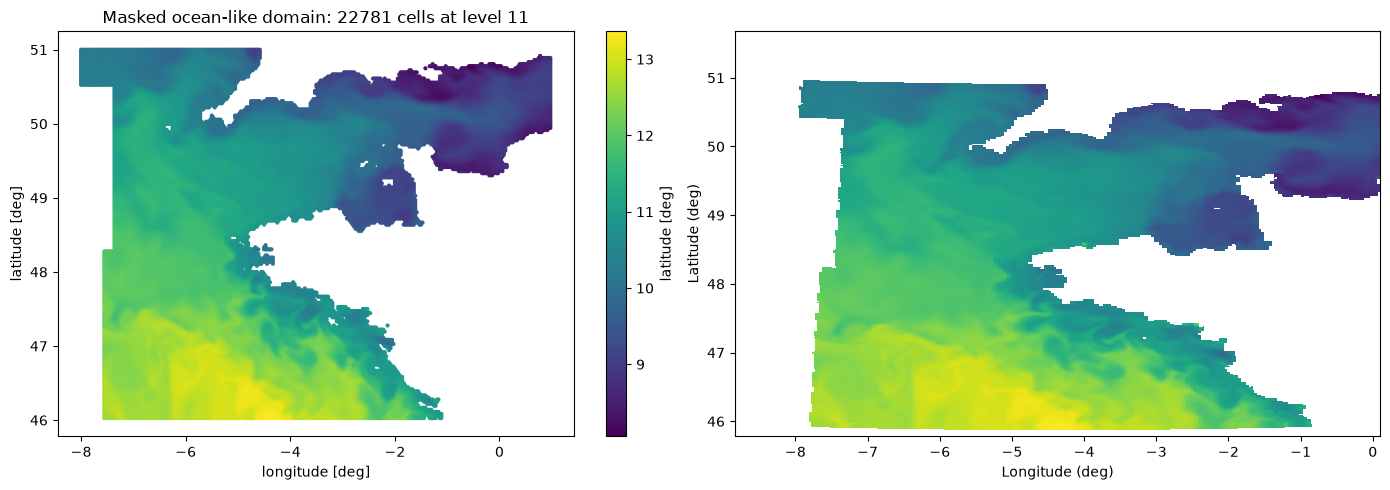

In [6]:
from foscat.Plot import lgnomproject

cell_ids=res.cell_ids
velocity = res.cell_data

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
plt.scatter(lon, lat, c=data, s=4, cmap="viridis")
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.title(f"Masked ocean-like domain: {len(res.cell_ids)} cells at level {LEVEL}")
plt.colorbar(label="latitude [deg]")
plt.tight_layout()
lgnomproject(res.cell_ids,res.cell_data, 2**LEVEL,hold=False,sub=(1,2,2),interp=True)

## Synthetic velocity field and full-depth pyramid

`Jmax=-1` performs every possible Down operation, here from level 5 to level 0. Therefore the result contains five detail maps and one final coarse map.

In [ ]:
lon_rad = torch.as_tensor(np.deg2rad(lon), dtype=torch.float64, device=device)
lat_rad = torch.as_tensor(np.deg2rad(lat), dtype=torch.float64, device=device)
velocity = torch.stack((torch.tensor(res.cell_data.astype('float64')), torch.tensor(res.cell_data.astype('float64'))), dim=0).unsqueeze(0).to(device)  # [B=1, C=2, N]

t0 = time.perf_counter()
decomp = HealPixDecomp(
    level=LEVEL,
    cell_ids=cell_ids,
    Jmax=-1,
    ellipsoid="sphere",
    dtype=torch.float64,
    device=device,
)
build_seconds = time.perf_counter() - t0
pyramid = decomp.compute(velocity)

print(decomp)
print("operator build [s]:", build_seconds)
print("levels:", pyramid.levels)
print("sizes :", [band.shape[-1] for band in pyramid])
assert decomp.n_scales == LEVEL
assert len(pyramid) == LEVEL + 1
assert pyramid.levels == tuple(range(LEVEL, -1, -1))
for band, ids in zip(pyramid, pyramid.cell_ids):
    assert band.shape[:-1] == velocity.shape[:-1]
    assert band.shape[-1] == len(ids)

## Exact inversion and exact cell ordering

The same paired Up prediction is subtracted during analysis and added during synthesis. Reconstruction is consequently an algebraic identity up to floating-point round-off, even though Down and Up are not mutual inverses.

In [ ]:
reconstructed = decomp.invert(pyramid)
error = reconstructed - velocity
max_abs = error.abs().max().item()
rel_rms = (
    error.square().mean().sqrt()
    / velocity.square().mean().sqrt().clamp_min(1e-15)
).item()
print({"max_abs": max_abs, "relative_rms": rel_rms})
assert reconstructed.shape == velocity.shape
assert torch.allclose(reconstructed, velocity, rtol=1e-11, atol=1e-12)

## Direct sum of fine-resolution components

The compact bands live on different native grids and cannot be added directly. `expand` lifts each band through the required paired Up operators. Their sum then equals the input.

In [ ]:
components = decomp.expand(pyramid)
direct_sum = torch.stack(components, dim=0).sum(dim=0)
sum_max_abs = (direct_sum - velocity).abs().max().item()
print({"expanded_components": len(components), "sum_max_abs": sum_max_abs})
assert len(components) == len(pyramid)
assert torch.allclose(direct_sum, velocity, rtol=1e-11, atol=1e-12)

## Native-scale bands

Each panel uses the exact NESTED IDs stored with its band. This is the metadata that later scale-dependent divergence/curl filters will consume.

In [ ]:
fig= plt.figure(figsize=(14, 8))
for index, (ax, band, ids, level) in enumerate(
    zip(axes.ravel(), pyramid, pyramid.cell_ids, pyramid.levels)
):
    band_lon, band_lat = healpix_geo.nested.healpix_to_lonlat(
        ids.tolist(), level, ellipsoid="sphere"
    )
    values = band[0, 0].detach().cpu().numpy()
    kind = "coarse" if index == len(pyramid) - 1 else "detail"
    
    lgnomproject(ids.tolist(),values, 2**level,hold=False,sub=(2,3,1+index),title=f"{kind}, level={level}, N={len(ids)}",cbar=True)

## Constant field on the masked domain

With the default L1-normalised local Down filter and column-normalised Up, a constant field should have negligible detail coefficients, including along the artificial coastline. Exact reconstruction is the strict invariant.

In [ ]:
constant = torch.ones((1, 1, len(cell_ids)), dtype=torch.float64, device=device)
constant_pyramid = decomp.compute(constant)
constant_rec = decomp.invert(constant_pyramid)
detail_max = [band.abs().max().item() for band in constant_pyramid.details]
print("detail maxima:", detail_max)
print("reconstruction max abs:", (constant_rec - constant).abs().max().item())
assert torch.allclose(constant_rec, constant, rtol=1e-11, atol=1e-12)

## Differentiability

Analysis and synthesis use Torch sparse matrix operations and preserve the autograd graph.

In [ ]:
learnable = velocity.detach().clone().requires_grad_(True)
learnable_pyramid = decomp.compute(learnable)
loss = sum(band.square().mean() for band in learnable_pyramid)
loss.backward()
assert learnable.grad is not None
assert torch.isfinite(learnable.grad).all()
print({"loss": loss.item(), "gradient_norm": learnable.grad.norm().item()})

## NumPy and explicit `Jmax` interoperability

In [ ]:
short_decomp = HealPixDecomp(
    level=LEVEL, cell_ids=cell_ids, Jmax=2, ellipsoid="sphere",
    dtype=torch.float64, device=device,
)
numpy_velocity = velocity[0].detach().cpu().numpy()
numpy_pyramid = short_decomp.compute(numpy_velocity)
numpy_rec = short_decomp.invert(numpy_pyramid)
assert len(numpy_pyramid) == 3  # two Down operations + final coarse map
assert isinstance(numpy_rec, np.ndarray)
assert np.allclose(numpy_rec, numpy_velocity, rtol=1e-11, atol=1e-12)
print({"bands": len(numpy_pyramid), "max_abs": np.max(np.abs(numpy_rec - numpy_velocity))})

## Result

The multiscale representation is compact, local, mask-aware, differentiable, and exactly invertible. It is a Laplacian pyramid rather than an orthogonal wavelet basis: bands can be correlated and their energies need not sum to input energy. `HealPixMultiScaleDivCurl` provides the physical, scale-dependent local kernels that map each `(u, v)` band to divergence and curl.